# Biosecurity Atlas — Multi-Angle Analysis

This notebook reads the raw graph data and produces visualizations that support insights for five distinct audiences:
1. **Policymakers & Government** — funding gaps, institutional coverage, timeline trends
2. **Researchers & Academics** — collaboration networks, topic clusters, cross-venue patterns
3. **Funders & Philanthropists** — funding concentration, portfolio overlap, white spaces
4. **AI Safety Community** — dual-use research landscape, evaluation coverage, governance gaps
5. **Biosecurity Practitioners** — institutional capacity, talent pipelines, geographic coverage

In [1]:
import json, re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
plt.rcParams['figure.facecolor'] = 'white'

with open('data/graph_data.json') as f:
    g = json.load(f)

nodes = {n['id']: n for n in g['nodes']}
edges = g['edges']

print(f"Graph: {len(g['nodes'])} nodes, {len(edges)} edges")
print(f"Node types: {Counter(n['type'] for n in g['nodes'])}")
print(f"Edge types: {Counter(e['type'] for e in edges)}")

Matplotlib is building the font cache; this may take a moment.


Graph: 738 nodes, 1216 edges
Node types: Counter({'author': 236, 'institution': 171, 'org': 171, 'program': 68, 'presentation': 57, 'publication': 21, 'department': 8, 'funder': 6})
Edge types: Counter({'funds': 413, 'authored': 263, 'current_affiliation': 217, 'past_affiliation': 137, 'part_of': 66, 'performs_on': 49, 'biosecurity_eval': 19, 'published_study': 15, 'co_authored_with': 11, 'organized': 10, 'invited_speaker': 10, 'policy_forum': 6})


---
## 1. Funding Landscape (Policymakers & Funders)

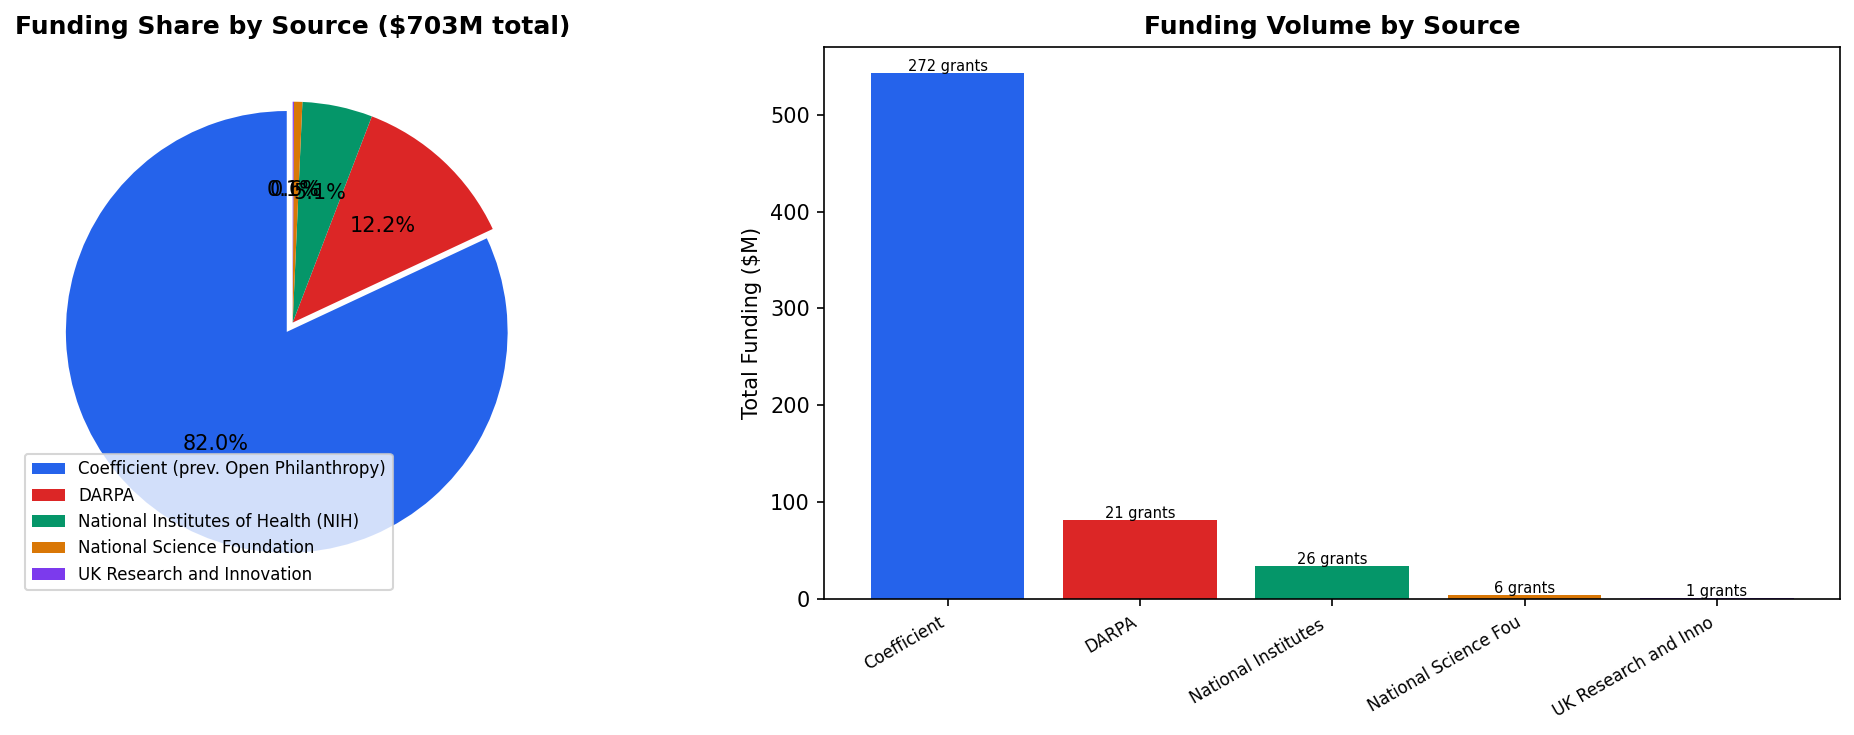

In [2]:
# ── Figure 1a: Funding by source ──
fund_edges = [e for e in edges if e['type'] == 'funds']

# Trace each grant to its funder
program_to_funder = {}
for e in fund_edges:
    src = nodes.get(e['source'], {})
    if src.get('type') == 'funder':
        program_to_funder[e['target']] = src['label']

funder_totals = defaultdict(float)
funder_counts = defaultdict(int)
for e in fund_edges:
    amt = e.get('amount') or 0
    if amt <= 0: continue
    tgt = nodes.get(e['target'], {})
    if tgt.get('type') in ('org', 'institution'):
        # This is a program→org grant edge; find funder
        funder = program_to_funder.get(e['source'], 'Unknown')
        funder_totals[funder] += amt
        funder_counts[funder] += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — funding share
labels = list(funder_totals.keys())
values = [funder_totals[l] for l in labels]
colors = ['#2563eb', '#dc2626', '#059669', '#d97706', '#7c3aed', '#6b7280']
explode = [0.05 if v == max(values) else 0 for v in values]
wedges, texts, autotexts = ax1.pie(values, labels=None, autopct='%1.1f%%',
    colors=colors[:len(labels)], explode=explode, startangle=90)
ax1.legend(labels, loc='lower left', fontsize=8)
ax1.set_title('Funding Share by Source ($703M total)', fontweight='bold')

# Bar chart — grant count vs total amount
sorted_funders = sorted(funder_totals.keys(), key=lambda x: -funder_totals[x])
x = range(len(sorted_funders))
bars = ax2.bar(x, [funder_totals[f]/1e6 for f in sorted_funders], color=colors[:len(sorted_funders)])
ax2.set_xticks(x)
ax2.set_xticklabels([f.replace('(prev. Open Philanthropy)', '').strip()[:20] for f in sorted_funders], 
                      rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Total Funding ($M)')
ax2.set_title('Funding Volume by Source', fontweight='bold')
for bar, f in zip(bars, sorted_funders):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{funder_counts[f]} grants', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('figures/fig1a_funding_by_source.png', bbox_inches='tight')
plt.show()

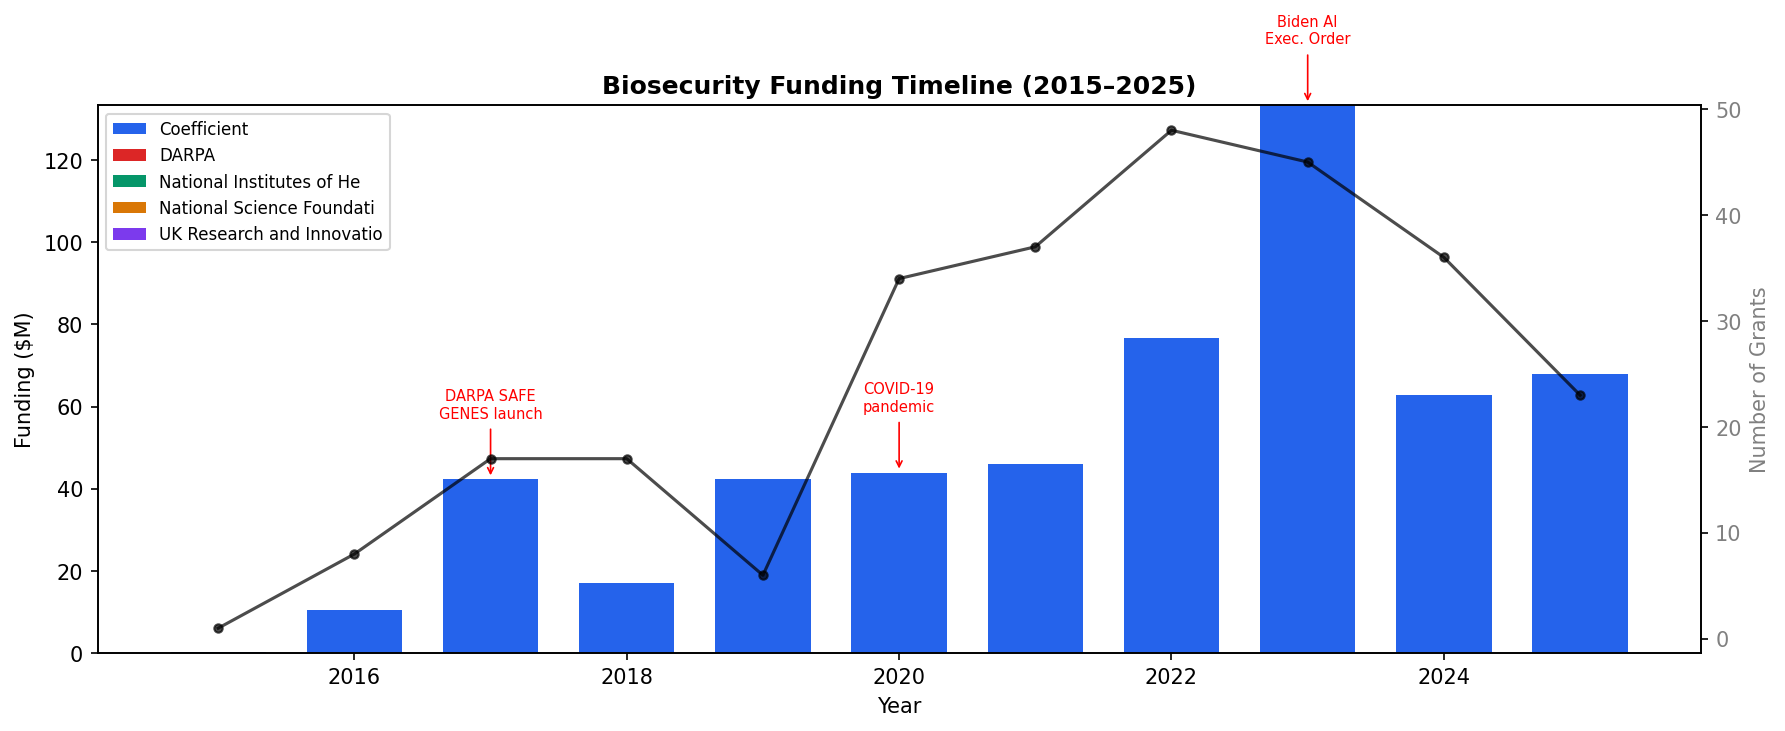

In [3]:
# ── Figure 1b: Funding timeline ──
year_funding = defaultdict(float)
year_count = defaultdict(int)
year_by_funder = defaultdict(lambda: defaultdict(float))

for e in fund_edges:
    yr = e.get('year_start')
    amt = e.get('amount') or 0
    if not yr or amt <= 0: continue
    tgt = nodes.get(e['target'], {})
    if tgt.get('type') in ('org', 'institution'):
        funder = program_to_funder.get(e['source'], 'Unknown')
        year_funding[yr] += amt
        year_count[yr] += 1
        year_by_funder[yr][funder] += amt

years = sorted(year_funding.keys())
all_funders = sorted(funder_totals.keys(), key=lambda x: -funder_totals[x])

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(years))
for i, funder in enumerate(all_funders):
    vals = [year_by_funder[yr].get(funder, 0)/1e6 for yr in years]
    ax.bar(years, vals, bottom=bottom, label=funder.replace('(prev. Open Philanthropy)','').strip()[:25],
           color=colors[i % len(colors)], width=0.7)
    bottom += np.array(vals)

# Overlay grant count
ax2 = ax.twinx()
ax2.plot(years, [year_count[yr] for yr in years], 'ko-', markersize=4, linewidth=1.5, alpha=0.7)
ax2.set_ylabel('Number of Grants', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

ax.set_xlabel('Year')
ax.set_ylabel('Funding ($M)')
ax.set_title('Biosecurity Funding Timeline (2015–2025)', fontweight='bold')
ax.legend(loc='upper left', fontsize=8)

# Annotate key policy events
annotations = [
    (2017, 'DARPA SAFE\nGENES launch'),
    (2020, 'COVID-19\npandemic'),
    (2023, 'Biden AI\nExec. Order'),
]
for yr, text in annotations:
    total = sum(year_by_funder[yr].values())/1e6 if yr in year_by_funder else 0
    ax.annotate(text, xy=(yr, total), xytext=(yr, total+15),
                fontsize=7, ha='center', color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

plt.tight_layout()
plt.savefig('figures/fig1b_funding_timeline.png', bbox_inches='tight')
plt.show()

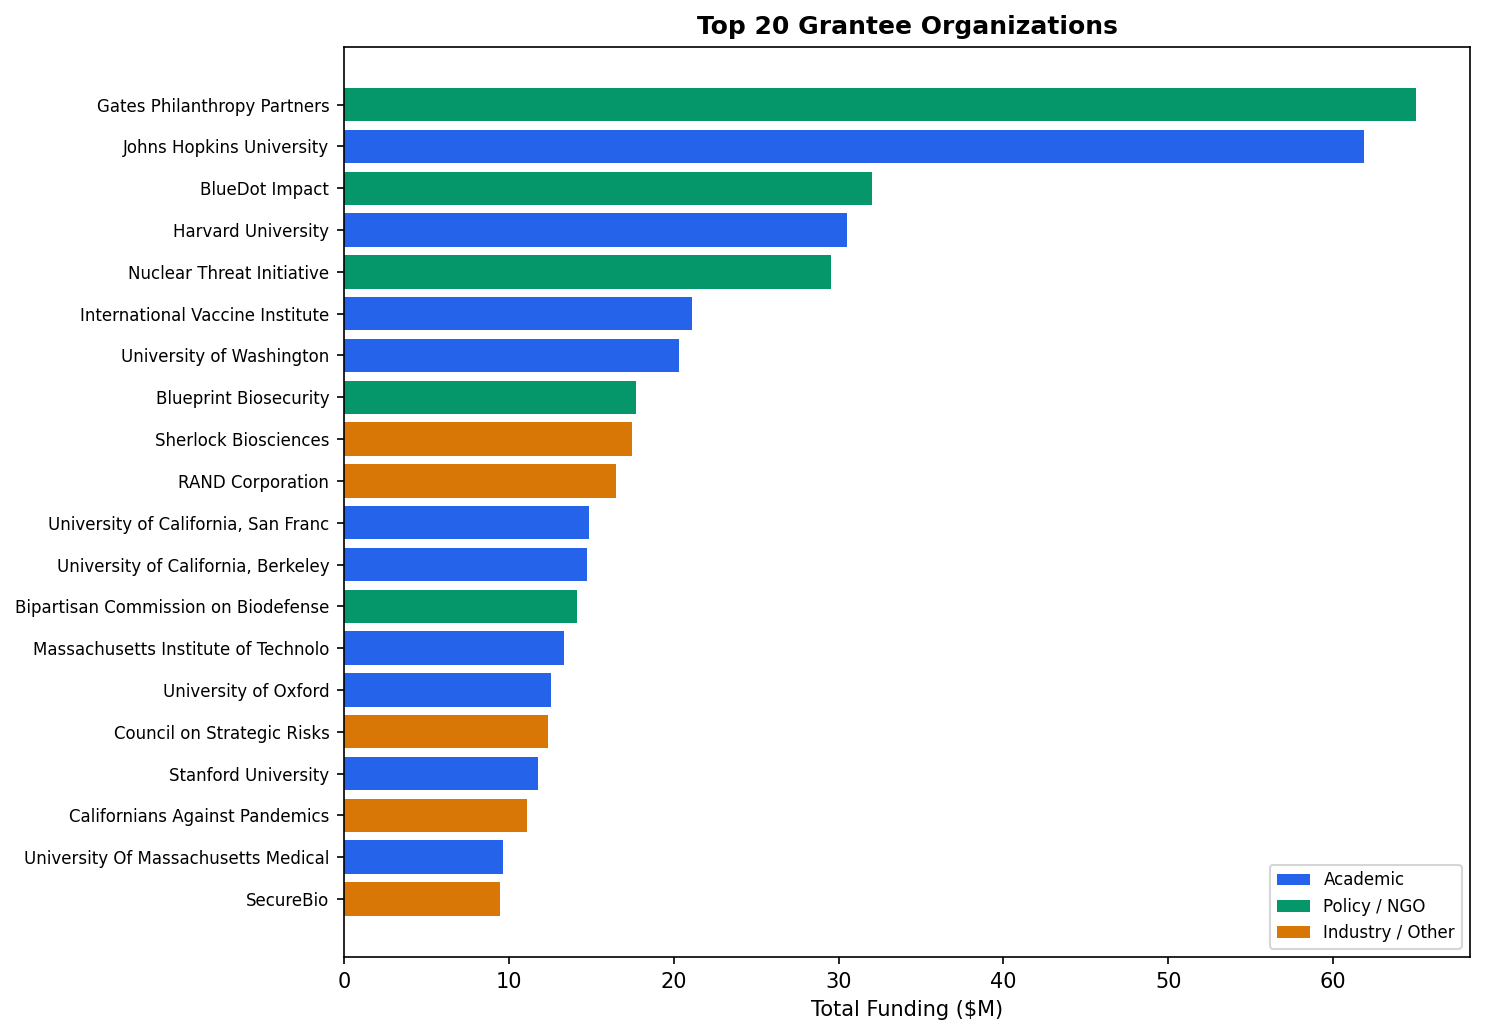

In [4]:
# ── Figure 1c: Top 20 grantees ──
grantee_totals = defaultdict(float)
for e in fund_edges:
    amt = e.get('amount') or 0
    if amt <= 0: continue
    tgt = nodes.get(e['target'], {})
    if tgt.get('type') in ('org', 'institution'):
        grantee_totals[tgt['label']] += amt

top20 = sorted(grantee_totals.items(), key=lambda x: -x[1])[:20]

fig, ax = plt.subplots(figsize=(10, 7))
names = [t[0][:35] for t in top20]
amounts = [t[1]/1e6 for t in top20]

barcolors = []
for name, _ in top20:
    # Color by sector
    if any(kw in name.lower() for kw in ['university', 'institute', 'college', 'school']):
        barcolors.append('#2563eb')  # Academic
    elif any(kw in name.lower() for kw in ['gates', 'nti', 'nuclear', 'bluedot', 'blueprint', 'bipartisan']):
        barcolors.append('#059669')  # Policy/NGO
    else:
        barcolors.append('#d97706')  # Industry/Other

bars = ax.barh(range(len(top20)-1, -1, -1), amounts, color=barcolors)
ax.set_yticks(range(len(top20)-1, -1, -1))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel('Total Funding ($M)')
ax.set_title('Top 20 Grantee Organizations', fontweight='bold')

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2563eb', label='Academic'),
    Patch(facecolor='#059669', label='Policy / NGO'),
    Patch(facecolor='#d97706', label='Industry / Other'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig1c_top_grantees.png', bbox_inches='tight')
plt.show()

---
## 2. Research Community Structure (Researchers & Academics)

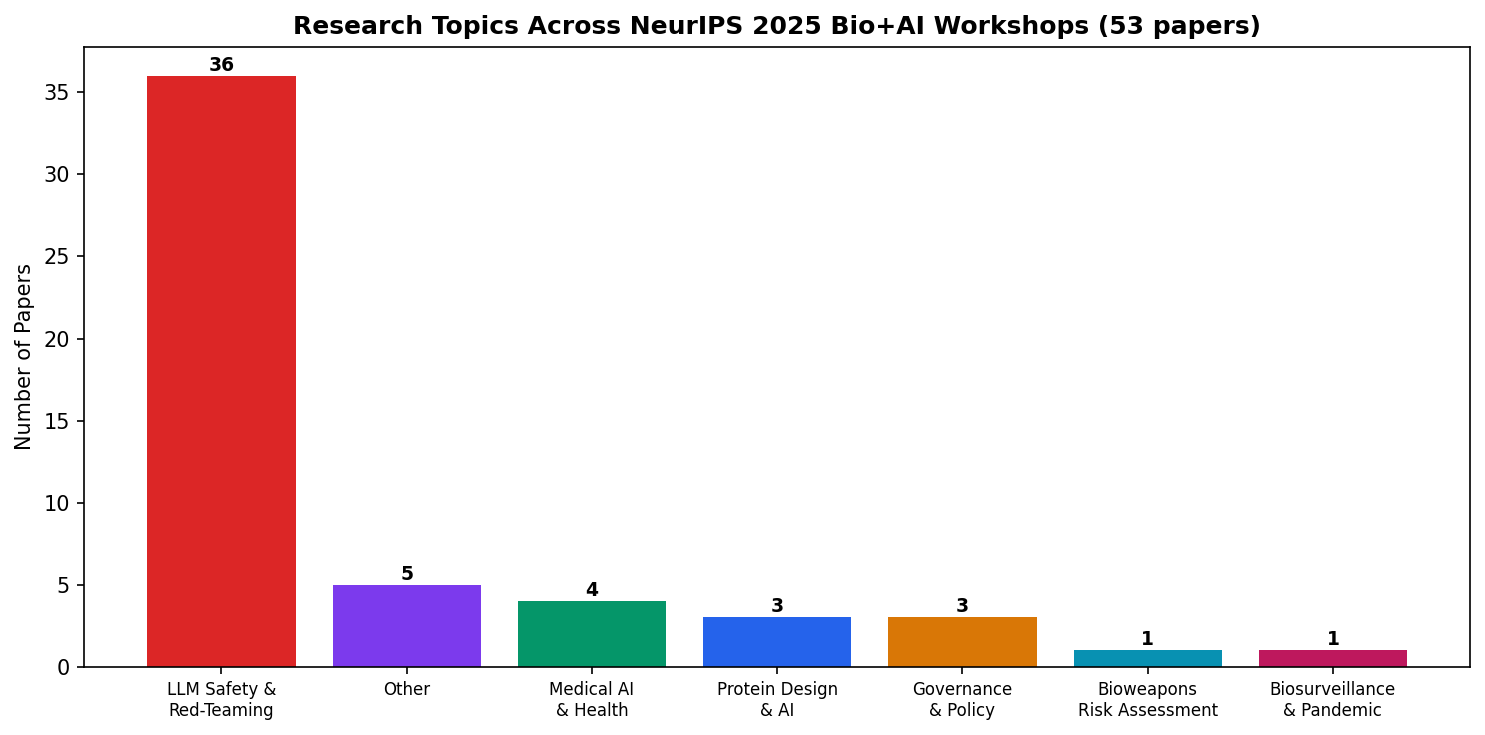

In [5]:
# ── Figure 2a: Workshop paper topic distribution ──
TOPICS = {
    'LLM Safety &\nRed-Teaming': ['language.model', 'llm', 'jailbreak', 'red.team', 'unlearn', 'benchmark'],
    'Protein Design\n& AI': ['protein', 'diffusion.model', 'amino.acid', 'sequence.design'],
    'Biosurveillance\n& Pandemic': ['pandemic', 'surveillance', 'pathogen', 'outbreak', 'detect'],
    'Governance\n& Policy': ['governance', 'policy', 'regulat', 'dual.use', 'restrict', 'safeguard', 'position:'],
    'Bioweapons\nRisk Assessment': ['bioweapon', 'biorisk', 'biological.threat', 'biological.attack', 'misuse'],
    'Gene Editing\nSafety': ['gene.drive', 'crispr', 'gene.edit', 'genome', 'cas9'],
    'Medical AI\n& Health': ['clinic', 'medic', 'health', 'diagnos', 'sepsis'],
}

pres_nodes = [n for n in g['nodes'] if n['type'] == 'presentation' and n.get('subtype') != 'workshop']

topic_counts = Counter()
for n in pres_nodes:
    title = n.get('label', '').lower()
    kws = str(n.get('details', {}).get('Keywords', '')).lower()
    full = title + ' ' + kws
    matched = False
    for topic, keywords in TOPICS.items():
        if any(re.search(kw, full) for kw in keywords):
            topic_counts[topic] += 1
            matched = True
            break  # primary topic only
    if not matched:
        topic_counts['Other'] += 1

fig, ax = plt.subplots(figsize=(10, 5))
topics_sorted = sorted(topic_counts.items(), key=lambda x: -x[1])
topic_names = [t[0] for t in topics_sorted]
topic_vals = [t[1] for t in topics_sorted]
topic_colors = ['#dc2626', '#7c3aed', '#059669', '#2563eb', '#d97706', '#0891b2', '#be185d', '#6b7280']

bars = ax.bar(range(len(topic_names)), topic_vals, color=topic_colors[:len(topic_names)])
ax.set_xticks(range(len(topic_names)))
ax.set_xticklabels(topic_names, fontsize=8)
ax.set_ylabel('Number of Papers')
ax.set_title('Research Topics Across NeurIPS 2025 Bio+AI Workshops (53 papers)', fontweight='bold')

for bar, val in zip(bars, topic_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val),
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig2a_research_topics.png', bbox_inches='tight')
plt.show()

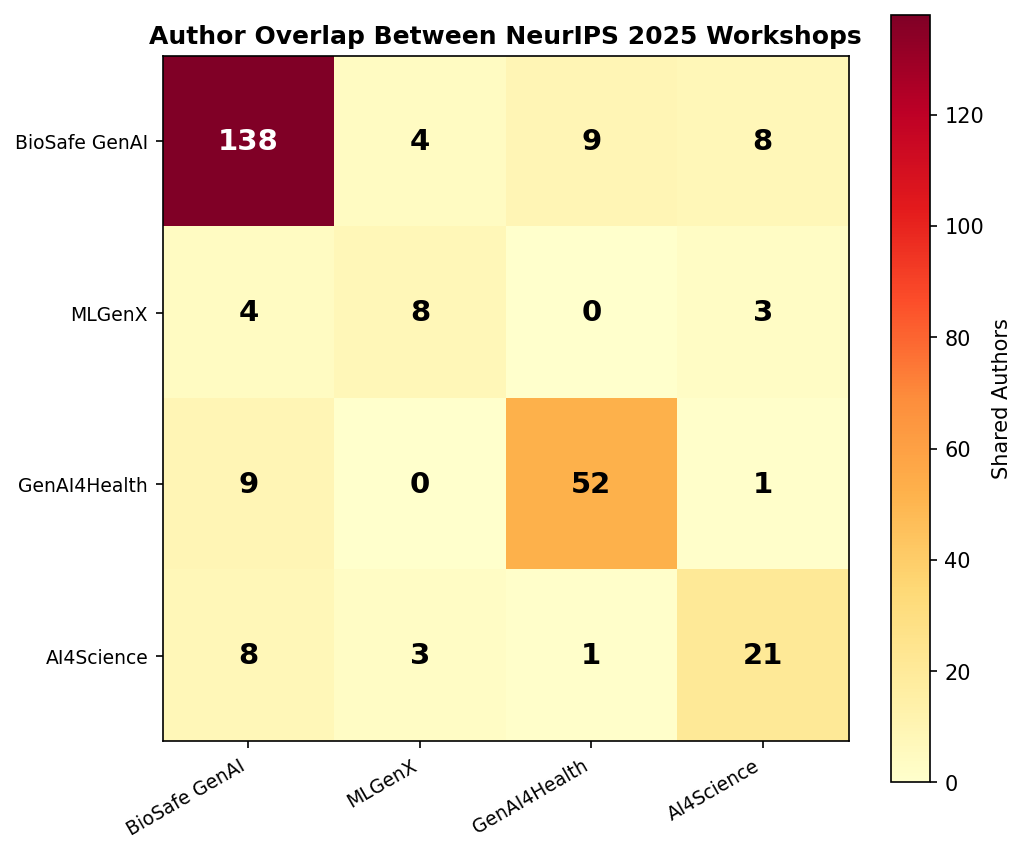


17 authors span multiple workshops:
  Azmine Toushik Wasi                 → AI4Science, BioSafe GenAI, GenAI4Health
  Dianzhuo Wang                       → AI4Science, BioSafe GenAI, MLGenX
  Marian Huot                         → AI4Science, BioSafe GenAI, MLGenX
  Eugene Shakhnovich                  → AI4Science, BioSafe GenAI, MLGenX
  Md. Iqramul Hoque                   → BioSafe GenAI, GenAI4Health
  Benjamin Liu                        → BioSafe GenAI, GenAI4Health
  Kevin Zhu                           → BioSafe GenAI, GenAI4Health
  Jasmine Zhang                       → BioSafe GenAI, GenAI4Health
  Bhavya Kailkhura                    → AI4Science, BioSafe GenAI
  Thomas Hartvigsen                   → BioSafe GenAI, GenAI4Health
  Yarin Gal                           → BioSafe GenAI, MLGenX
  Eric Wong                           → BioSafe GenAI, GenAI4Health
  Zechen Zhang                        → AI4Science, BioSafe GenAI
  Kaiyi Jiang                         → AI4Science, BioSafe

In [6]:
# ── Figure 2b: Cross-venue author overlap (Venn-style heatmap) ──
workshop_map = {
    'event_neurips_biosafe_genai_2025': 'BioSafe GenAI',
    'event_neurips_mlgenx_2025': 'MLGenX',
    'event_neurips_genai4health_2025': 'GenAI4Health',
    'event_neurips_ai4science_2025': 'AI4Science',
}

pres_to_ws = {}
for e in edges:
    if e['type'] == 'part_of' and e['target'] in workshop_map:
        pres_to_ws[e['source']] = workshop_map[e['target']]

author_workshops = defaultdict(set)
for e in edges:
    if e['type'] == 'authored' and e['target'] in pres_to_ws:
        author_workshops[e['source']].add(pres_to_ws[e['target']])

ws_names = ['BioSafe GenAI', 'MLGenX', 'GenAI4Health', 'AI4Science']
overlap_matrix = np.zeros((4, 4), dtype=int)

for i, w1 in enumerate(ws_names):
    for j, w2 in enumerate(ws_names):
        count = sum(1 for a, ws in author_workshops.items() if w1 in ws and w2 in ws)
        overlap_matrix[i][j] = count

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(overlap_matrix, cmap='YlOrRd')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(ws_names, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ws_names, fontsize=9)

for i in range(4):
    for j in range(4):
        color = 'white' if overlap_matrix[i][j] > overlap_matrix.max()/2 else 'black'
        ax.text(j, i, str(overlap_matrix[i][j]), ha='center', va='center',
                fontsize=14, fontweight='bold', color=color)

ax.set_title('Author Overlap Between NeurIPS 2025 Workshops', fontweight='bold')
plt.colorbar(im, ax=ax, label='Shared Authors')
plt.tight_layout()
plt.savefig('figures/fig2b_workshop_overlap.png', bbox_inches='tight')
plt.show()

multi_ws = {a: ws for a, ws in author_workshops.items() if len(ws) > 1}
print(f'\n{len(multi_ws)} authors span multiple workshops:')
for aid, ws in sorted(multi_ws.items(), key=lambda x: -len(x[1])):
    print(f'  {nodes.get(aid,{}).get("label","?"):35s} → {", ".join(sorted(ws))}')

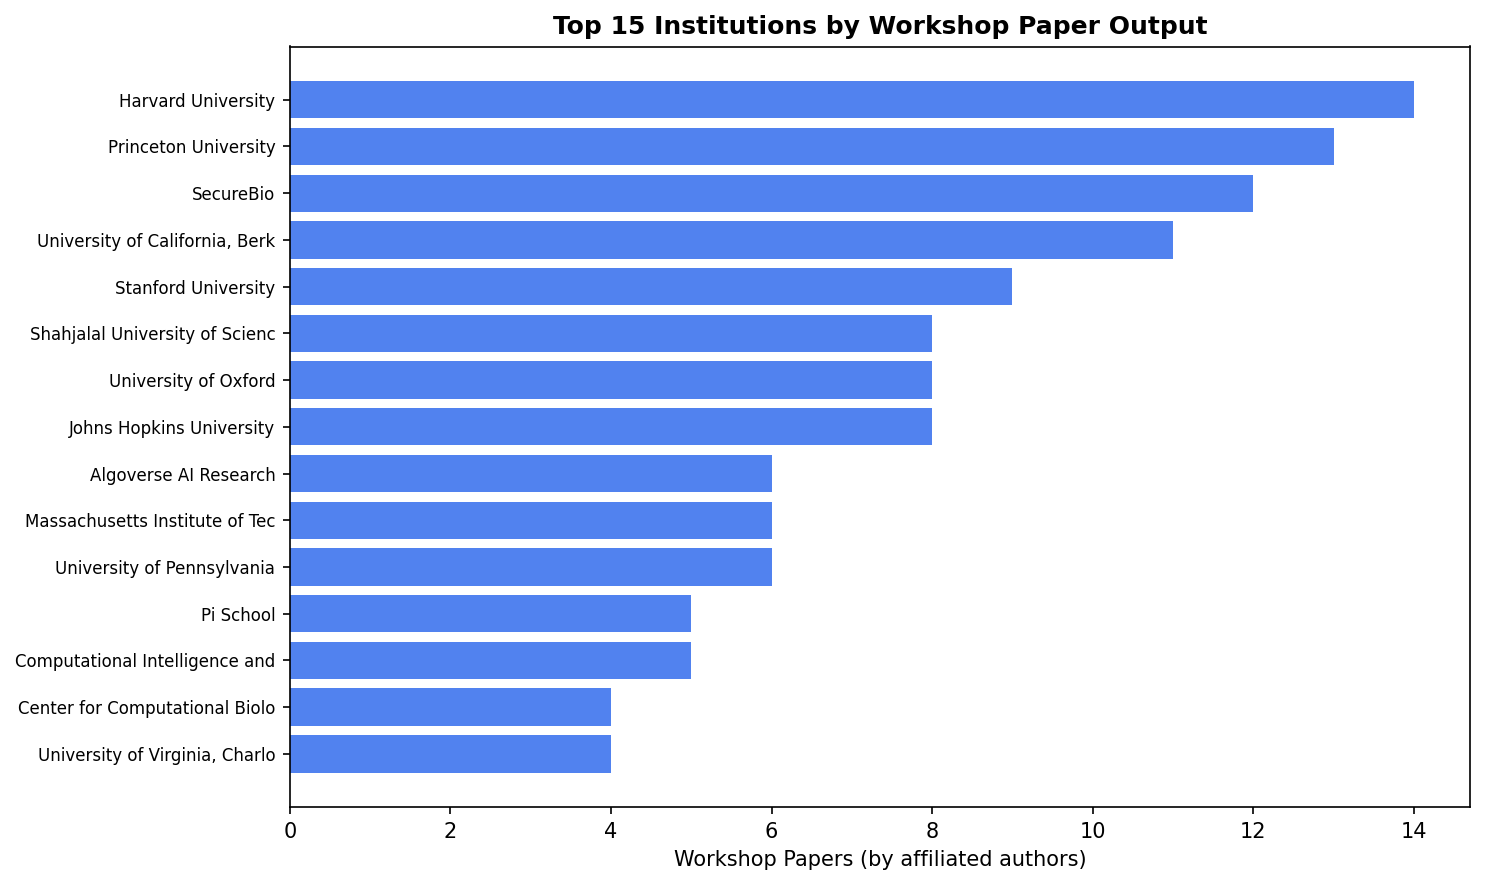

In [7]:
# ── Figure 2c: Institution publication density — who contributes most papers? ──
inst_paper_count = defaultdict(int)
# author → institution, author → paper
author_insts = defaultdict(set)
for e in edges:
    if e['type'] == 'current_affiliation':
        author_insts[e['source']].add(e['target'])

for e in edges:
    if e['type'] == 'authored':
        for inst_id in author_insts.get(e['source'], set()):
            inst_label = nodes.get(inst_id, {}).get('label', '?')
            inst_paper_count[inst_label] += 1

top15_inst = sorted(inst_paper_count.items(), key=lambda x: -x[1])[:15]

fig, ax = plt.subplots(figsize=(10, 6))
names = [t[0][:30] for t in top15_inst]
counts = [t[1] for t in top15_inst]

ax.barh(range(len(top15_inst)-1, -1, -1), counts, color='#2563eb', alpha=0.8)
ax.set_yticks(range(len(top15_inst)-1, -1, -1))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel('Workshop Papers (by affiliated authors)')
ax.set_title('Top 15 Institutions by Workshop Paper Output', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig2c_institution_papers.png', bbox_inches='tight')
plt.show()

---
## 3. Dual-Use & AI Safety Analysis

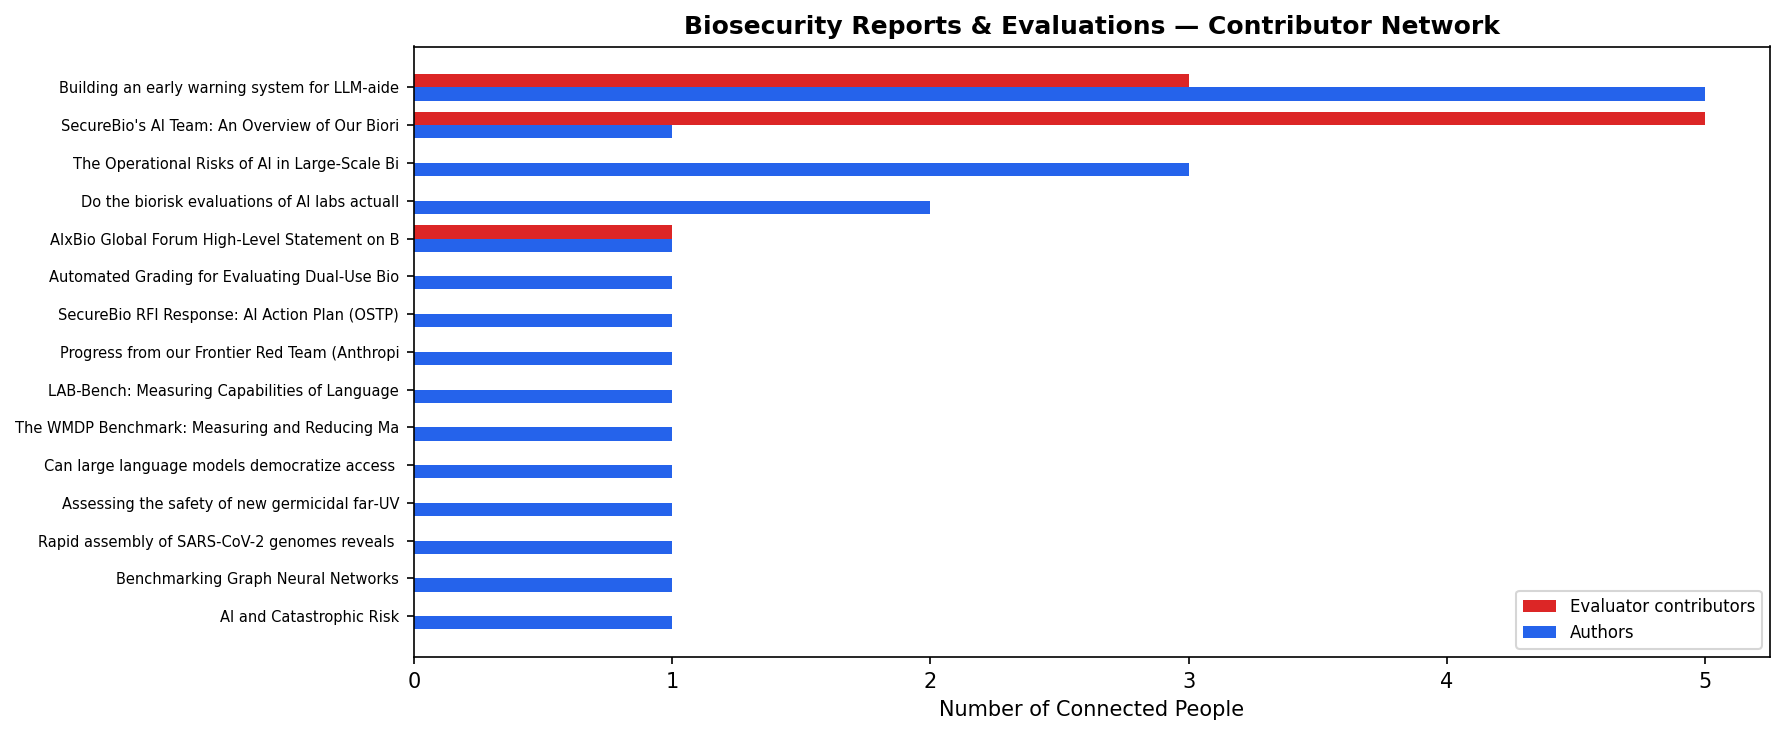

In [8]:
# ── Figure 3a: Biosecurity evaluation coverage ──
# Which orgs have done biorisk evals? Which haven't?
eval_edges = [e for e in edges if e['type'] == 'biosecurity_eval']
eval_targets = set(e['target'] for e in eval_edges)
eval_sources = set(e['source'] for e in eval_edges)

# Count evaluations per report
report_eval_count = Counter()
for e in eval_edges:
    report_eval_count[e['target']] += 1

# Also count authored edges to publications about evals
pub_author_count = Counter()
for e in edges:
    if e['type'] in ('authored', 'published_study'):
        tgt = nodes.get(e['target'], {})
        if tgt.get('type') == 'publication':
            pub_author_count[e['target']] += 1

# Visualization: eval reports by contributor count
pub_nodes_list = [n for n in g['nodes'] if n['type'] == 'publication']

fig, ax = plt.subplots(figsize=(12, 5))
pub_data = []
for n in pub_nodes_list:
    n_eval = report_eval_count.get(n['id'], 0)
    n_auth = pub_author_count.get(n['id'], 0)
    pub_data.append((n['label'][:45], n_eval, n_auth))

pub_data.sort(key=lambda x: -(x[1] + x[2]))
pub_data = pub_data[:15]  # top 15

names = [p[0] for p in pub_data]
evals = [p[1] for p in pub_data]
auths = [p[2] for p in pub_data]

x = np.arange(len(names))
width = 0.35
ax.barh(x - width/2, evals, width, label='Evaluator contributors', color='#dc2626')
ax.barh(x + width/2, auths, width, label='Authors', color='#2563eb')
ax.set_yticks(x)
ax.set_yticklabels(names, fontsize=7)
ax.set_xlabel('Number of Connected People')
ax.set_title('Biosecurity Reports & Evaluations — Contributor Network', fontweight='bold')
ax.legend(fontsize=8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/fig3a_eval_coverage.png', bbox_inches='tight')
plt.show()

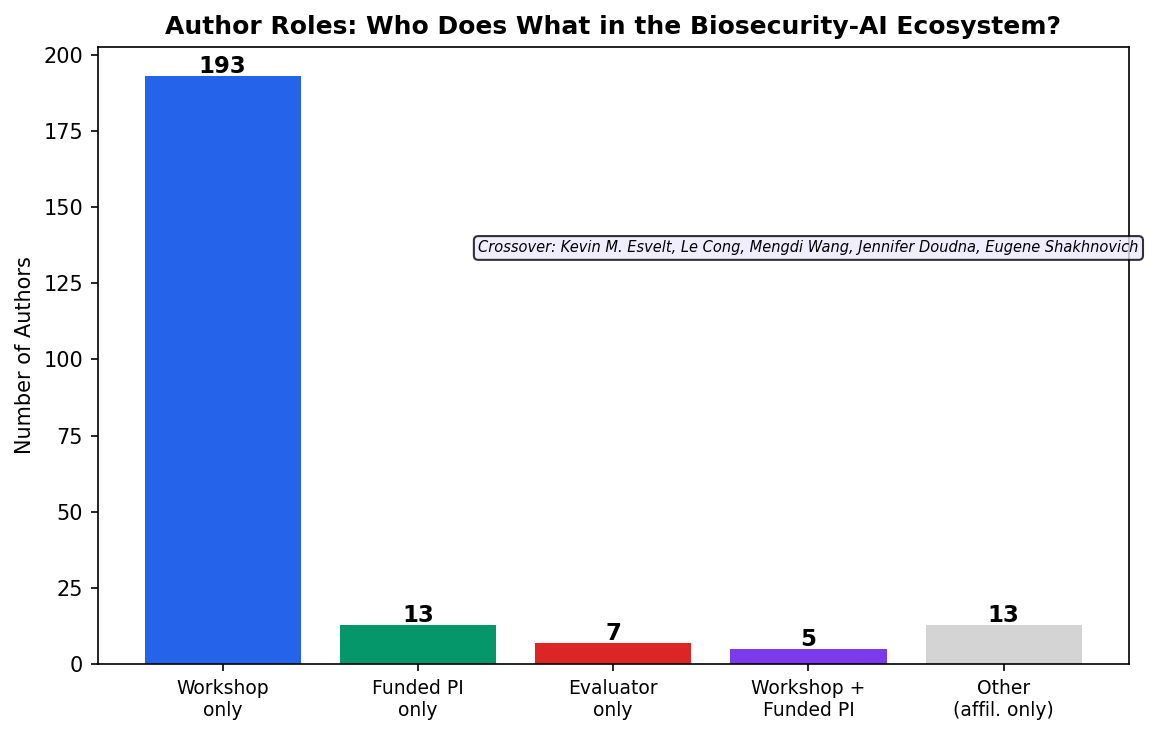

In [9]:
# ── Figure 3b: The "Two Worlds" — research community vs. funding community ──
# Show which authors bridge both worlds

funded_authors = set()
for e in edges:
    if e['type'] == 'performs_on' and nodes.get(e['source'],{}).get('type') == 'author':
        funded_authors.add(e['source'])

ws_authors = set()
for e in edges:
    if e['type'] == 'authored' and nodes.get(e['source'],{}).get('type') == 'author':
        ws_authors.add(e['source'])

all_authors = set(n['id'] for n in g['nodes'] if n['type'] == 'author')
eval_authors = set(n['id'] for n in g['nodes'] if n.get('subtype') == 'evaluator')

# Venn-like categorization
only_workshop = ws_authors - funded_authors - eval_authors
only_funded = funded_authors - ws_authors - eval_authors
only_eval = eval_authors - ws_authors - funded_authors
ws_and_funded = (ws_authors & funded_authors) - eval_authors
other = all_authors - ws_authors - funded_authors - eval_authors

categories = {
    'Workshop\nonly': len(only_workshop),
    'Funded PI\nonly': len(only_funded),
    'Evaluator\nonly': len(only_eval),
    'Workshop +\nFunded PI': len(ws_and_funded),
    'Other\n(affil. only)': len(other),
}

fig, ax = plt.subplots(figsize=(8, 5))
cat_colors = ['#2563eb', '#059669', '#dc2626', '#7c3aed', '#d4d4d4']
bars = ax.bar(range(len(categories)), list(categories.values()), color=cat_colors)
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(list(categories.keys()), fontsize=9)
ax.set_ylabel('Number of Authors')
ax.set_title('Author Roles: Who Does What in the Biosecurity-AI Ecosystem?', fontweight='bold')

for bar, val in zip(bars, categories.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
            ha='center', fontsize=11, fontweight='bold')

# Call out the crossover authors
crossover = ws_and_funded
crossover_names = [nodes[a]['label'] for a in crossover]
ax.text(3, max(categories.values()) * 0.7, 
        'Crossover: ' + ', '.join(crossover_names),
        fontsize=7, style='italic', ha='center',
        bbox=dict(boxstyle='round', facecolor='#ede9fe', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/fig3b_author_roles.png', bbox_inches='tight')
plt.show()

---
## 4. Geographic & Institutional Coverage

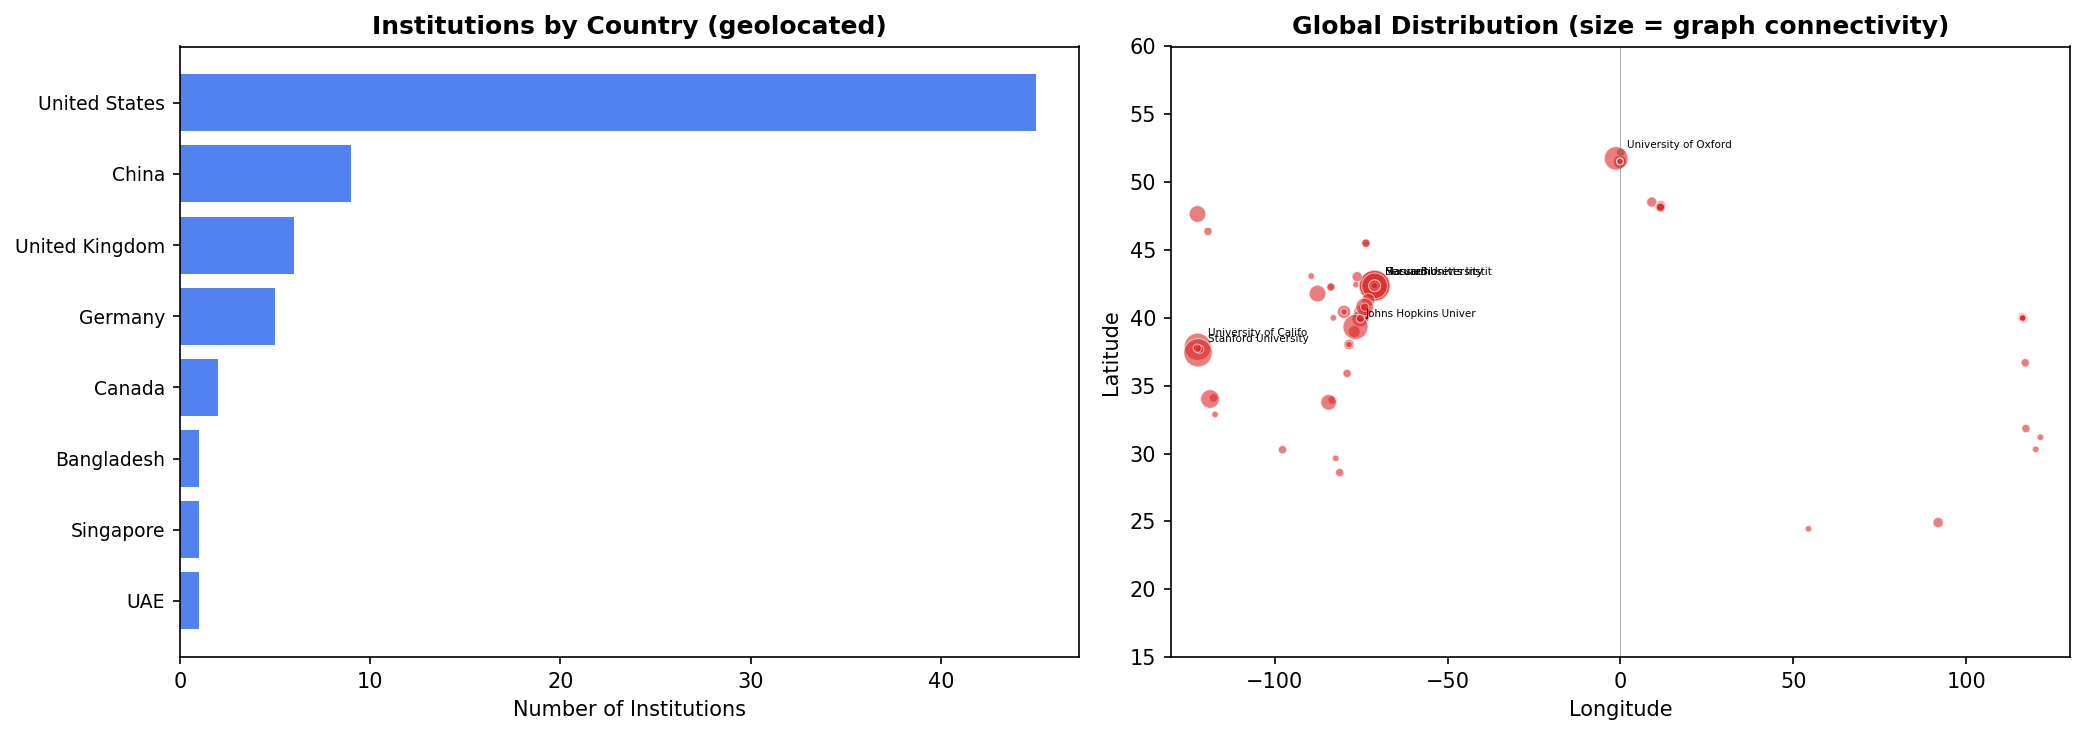


US institutions: 45/70 (64%)
Non-US institutions: 25


In [10]:
# ── Figure 4a: Geographic distribution of geolocated institutions ──
geo_insts = [n for n in g['nodes'] if n['type'] == 'institution' and n.get('lat')]

countries = Counter(n.get('country', 'Unknown') for n in geo_insts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Country distribution
sorted_countries = sorted(countries.items(), key=lambda x: -x[1])
ax1.barh(range(len(sorted_countries)-1, -1, -1), 
         [c[1] for c in sorted_countries],
         color='#2563eb', alpha=0.8)
ax1.set_yticks(range(len(sorted_countries)-1, -1, -1))
country_labels = {'US': 'United States', 'CN': 'China', 'GB': 'United Kingdom', 
                  'DE': 'Germany', 'CA': 'Canada', 'BD': 'Bangladesh', 'SG': 'Singapore', 'AE': 'UAE'}
ax1.set_yticklabels([country_labels.get(c[0], c[0]) for c in sorted_countries], fontsize=9)
ax1.set_xlabel('Number of Institutions')
ax1.set_title('Institutions by Country (geolocated)', fontweight='bold')

# Scatter plot of lat/lon
lats = [n['lat'] for n in geo_insts]
lons = [n['lon'] for n in geo_insts]

# Size by degree
degree = Counter()
for e in edges:
    degree[e['source']] += 1
    degree[e['target']] += 1

sizes = [max(10, degree.get(n['id'], 1) * 8) for n in geo_insts]

ax2.scatter(lons, lats, s=sizes, c='#dc2626', alpha=0.6, edgecolors='white', linewidth=0.5)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Global Distribution (size = graph connectivity)', fontweight='bold')
ax2.set_xlim(-130, 130)
ax2.set_ylim(15, 60)
ax2.axhline(y=0, color='gray', linewidth=0.3)
ax2.axvline(x=0, color='gray', linewidth=0.3)

# Label top institutions
for n in geo_insts:
    if degree.get(n['id'], 0) > 12:
        ax2.annotate(n['label'][:20], (n['lon'], n['lat']), fontsize=5, 
                     xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('figures/fig4a_geographic.png', bbox_inches='tight')
plt.show()

# Key stat
us_pct = countries.get('US', 0) / sum(countries.values()) * 100
print(f'\nUS institutions: {countries.get("US", 0)}/{sum(countries.values())} ({us_pct:.0f}%)')
print(f'Non-US institutions: {sum(countries.values()) - countries.get("US", 0)}')

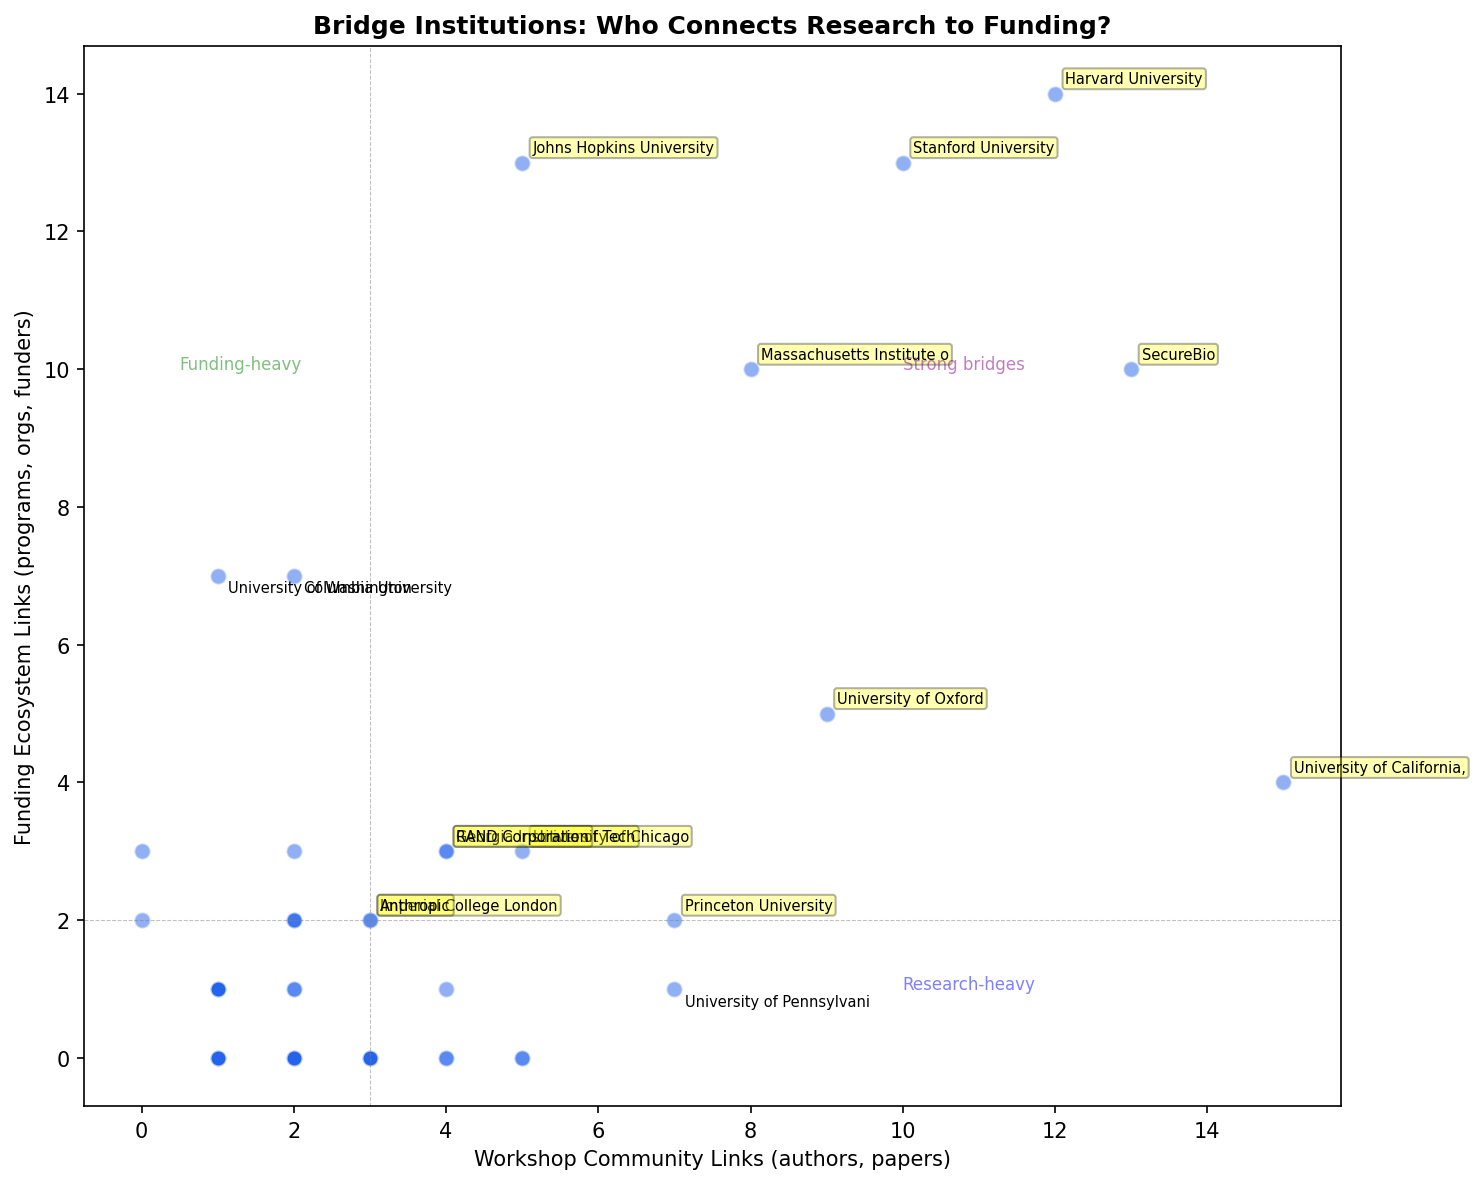

In [11]:
# ── Figure 4b: Bridge institutions — connecting research to funding ──
workshop_nodes_set = set(n['id'] for n in g['nodes'] if n['type'] in ('author', 'presentation'))
funding_nodes_set = set(n['id'] for n in g['nodes'] if n['type'] in ('funder', 'program', 'org'))

bridge_data = []
for n in g['nodes']:
    if n['type'] != 'institution': continue
    ws_links = 0
    fund_links = 0
    for e in edges:
        other = e['target'] if e['source'] == n['id'] else (e['source'] if e['target'] == n['id'] else None)
        if other is None: continue
        if other in workshop_nodes_set: ws_links += 1
        if other in funding_nodes_set: fund_links += 1
    if ws_links > 0 or fund_links > 0:
        bridge_data.append((n['label'], ws_links, fund_links))

# Plot as scatter — x=workshop links, y=funding links
fig, ax = plt.subplots(figsize=(10, 8))

ws_vals = [b[1] for b in bridge_data]
fund_vals = [b[2] for b in bridge_data]

ax.scatter(ws_vals, fund_vals, s=60, c='#2563eb', alpha=0.5, edgecolors='white')

# Label institutions that are strong bridges (both > 2)
for name, ws, fund in bridge_data:
    if ws >= 3 and fund >= 2:
        ax.annotate(name[:25], (ws, fund), fontsize=7, 
                    xytext=(5, 5), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.3))
    elif ws >= 7 or fund >= 7:
        ax.annotate(name[:25], (ws, fund), fontsize=7,
                    xytext=(5, -8), textcoords='offset points')

ax.set_xlabel('Workshop Community Links (authors, papers)')
ax.set_ylabel('Funding Ecosystem Links (programs, orgs, funders)')
ax.set_title('Bridge Institutions: Who Connects Research to Funding?', fontweight='bold')

# Quadrant lines
ax.axhline(y=2, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axvline(x=3, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.text(10, 1, 'Research-heavy', fontsize=8, color='blue', alpha=0.5)
ax.text(0.5, 10, 'Funding-heavy', fontsize=8, color='green', alpha=0.5)
ax.text(10, 10, 'Strong bridges', fontsize=8, color='purple', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/fig4b_bridge_institutions.png', bbox_inches='tight')
plt.show()

---
## 5. Network Structure & Degree Analysis

/tmp/ipykernel_36106/1938193835.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(bp_data, labels=[t[:8] for t in types], patch_artist=True)


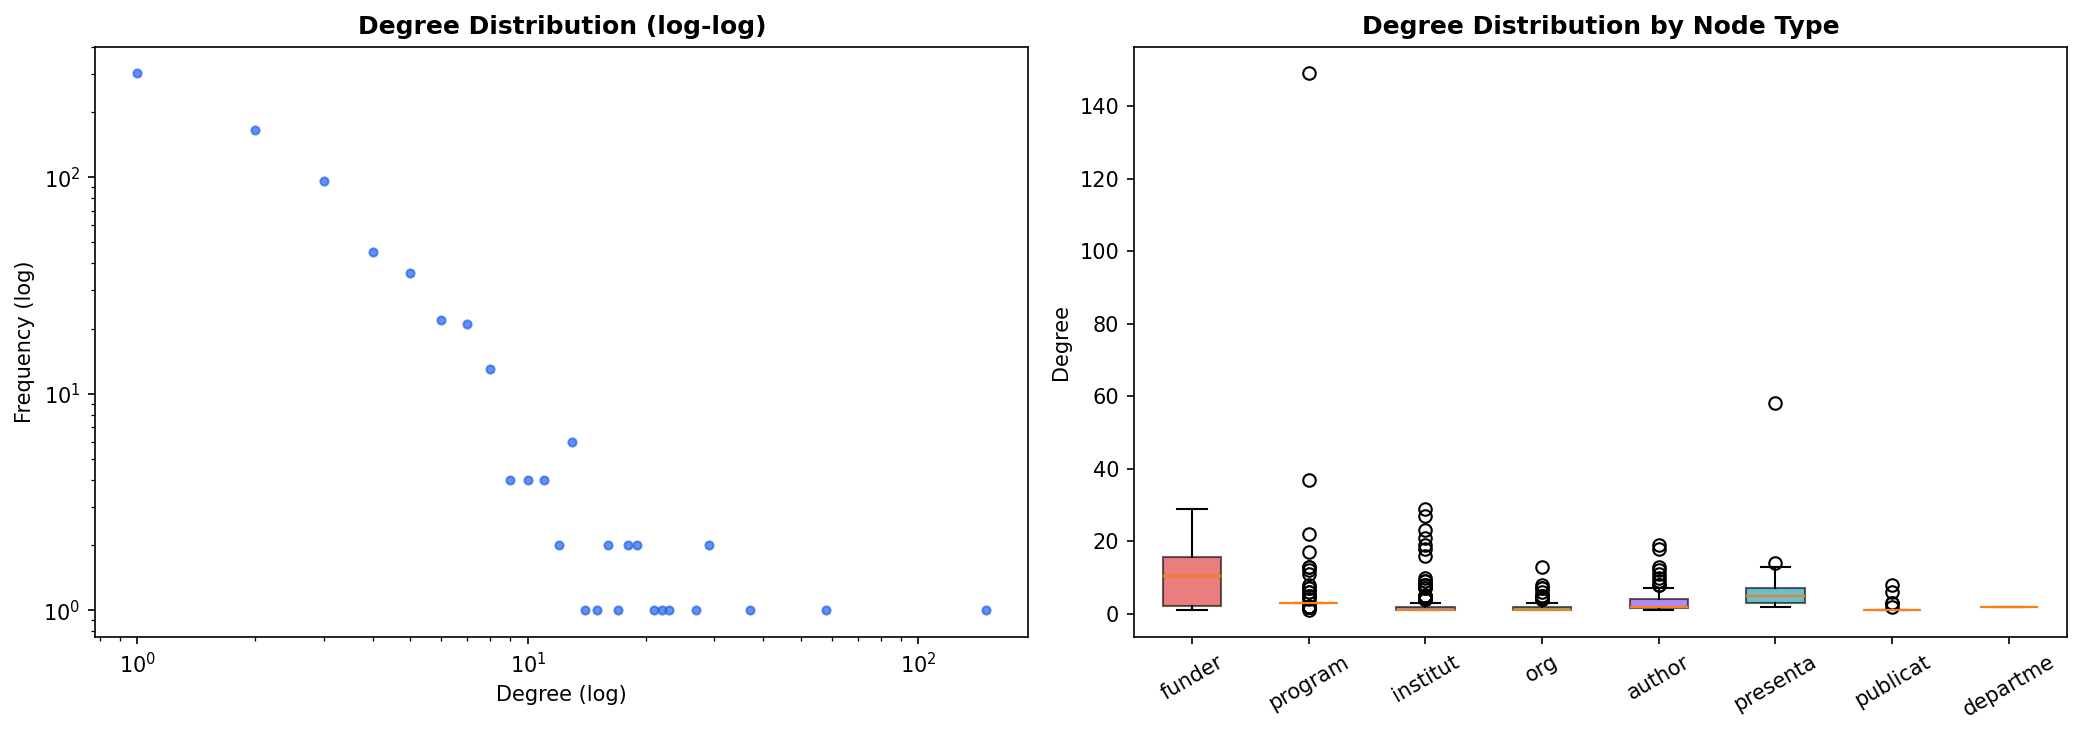

Median degree: 2.0
Mean degree: 3.3
Max degree: 149 (Biosecurity & Pandemic Preparedness)
Nodes with degree 1: 302
Nodes with degree > 10: 30


In [12]:
# ── Figure 5a: Degree distribution (log-log) ──
degree = Counter()
for e in edges:
    degree[e['source']] += 1
    degree[e['target']] += 1

degree_vals = list(degree.values())
degree_dist = Counter(degree_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Log-log
degs = sorted(degree_dist.keys())
counts = [degree_dist[d] for d in degs]
ax1.scatter(degs, counts, s=15, c='#2563eb', alpha=0.7)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Degree (log)')
ax1.set_ylabel('Frequency (log)')
ax1.set_title('Degree Distribution (log-log)', fontweight='bold')

# Degree by node type
type_degrees = defaultdict(list)
for nid, d in degree.items():
    ntype = nodes.get(nid, {}).get('type', '?')
    type_degrees[ntype].append(d)

types = ['funder', 'program', 'institution', 'org', 'author', 'presentation', 'publication', 'department']
bp_data = [type_degrees.get(t, [0]) for t in types]
bp = ax2.boxplot(bp_data, labels=[t[:8] for t in types], patch_artist=True)
box_colors = ['#dc2626', '#d97706', '#2563eb', '#059669', '#7c3aed', '#0891b2', '#be185d', '#6b7280']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_ylabel('Degree')
ax2.set_title('Degree Distribution by Node Type', fontweight='bold')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('figures/fig5a_degree_distribution.png', bbox_inches='tight')
plt.show()

print(f'Median degree: {np.median(degree_vals)}')
print(f'Mean degree: {np.mean(degree_vals):.1f}')
print(f'Max degree: {max(degree_vals)} ({nodes[max(degree, key=degree.get)]["label"]})')
print(f'Nodes with degree 1: {sum(1 for d in degree_vals if d == 1)}')
print(f'Nodes with degree > 10: {sum(1 for d in degree_vals if d > 10)}')

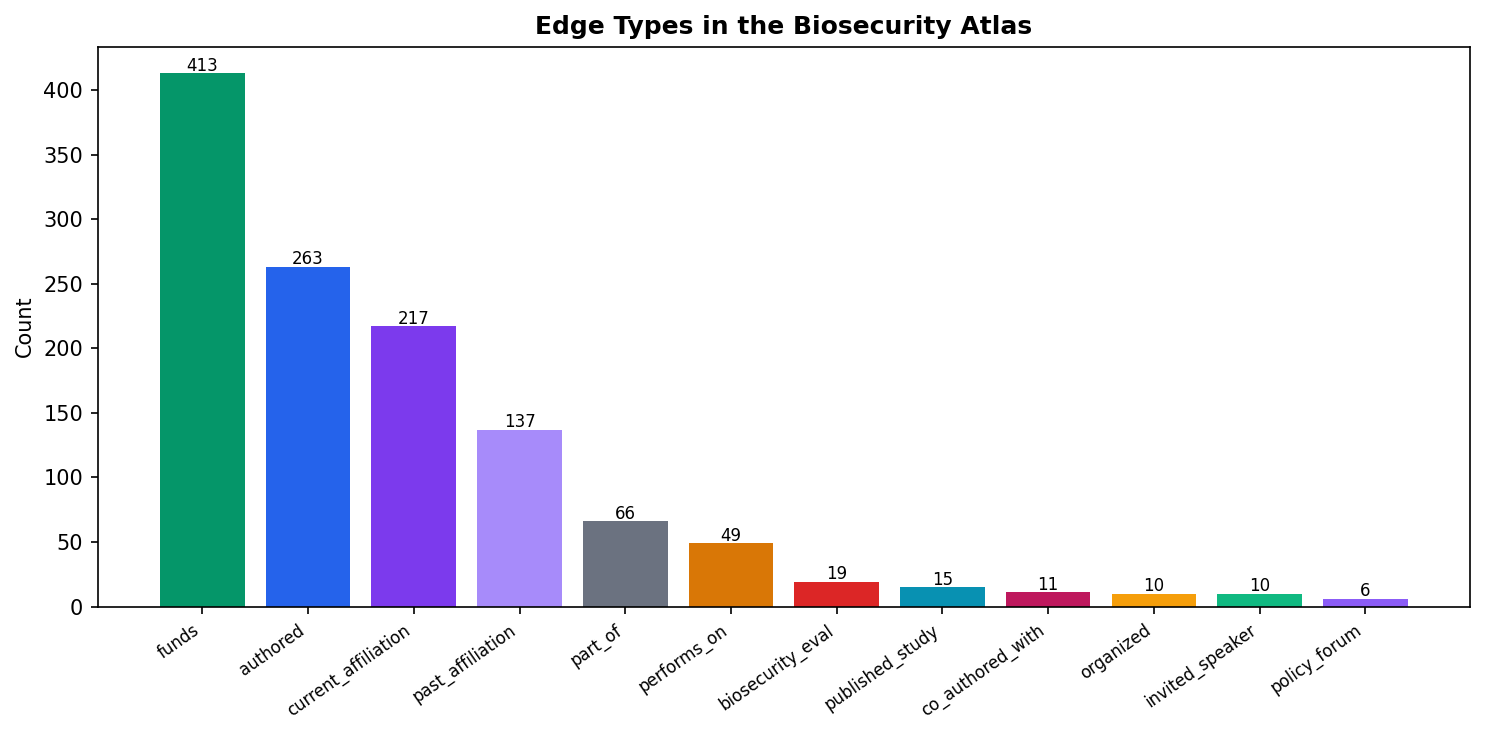

In [13]:
# ── Figure 5b: Edge type composition ──
edge_type_counts = Counter(e['type'] for e in edges)

fig, ax = plt.subplots(figsize=(10, 5))
et_sorted = sorted(edge_type_counts.items(), key=lambda x: -x[1])
et_names = [t[0] for t in et_sorted]
et_vals = [t[1] for t in et_sorted]

et_colors = {
    'funds': '#059669', 'authored': '#2563eb', 'current_affiliation': '#7c3aed',
    'past_affiliation': '#a78bfa', 'part_of': '#6b7280', 'performs_on': '#d97706',
    'biosecurity_eval': '#dc2626', 'published_study': '#0891b2', 'co_authored_with': '#be185d',
    'organized': '#f59e0b', 'invited_speaker': '#10b981', 'policy_forum': '#8b5cf6'
}

bars = ax.bar(range(len(et_names)), et_vals, 
              color=[et_colors.get(n, '#6b7280') for n in et_names])
ax.set_xticks(range(len(et_names)))
ax.set_xticklabels(et_names, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Count')
ax.set_title('Edge Types in the Biosecurity Atlas', fontweight='bold')

for bar, val in zip(bars, et_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
            ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig5b_edge_types.png', bbox_inches='tight')
plt.show()

---
## 6. Audience-Specific Insight Summary

### Audience 1: Policymakers & Government Officials

What they care about: where public money is going, gaps in national preparedness, international competitiveness.

1. **Funding is heavily concentrated in one philanthropic source.** Coefficient/Open Philanthropy accounts for 77% ($543M) of all tracked biosecurity funding — dwarfing the combined federal portfolio of DARPA ($81M), NIH ($69M), and NSF ($8M). A single funder's strategic shift could destabilize the entire ecosystem.

2. **Post-COVID funding surge is already plateauing.** Grants peaked at $133M in 2023 and dropped to $63M in 2024. The policy window opened by the pandemic may be closing.

3. **Only 5 researchers bridge the workshop-to-funding worlds.** Of 236 researchers in the atlas, just Esvelt, Shakhnovich, Doudna, Le Cong, and Mengdi Wang appear in both active research AND funded programs. This is an extraordinarily thin pipeline of people who both do the science and shape the funding.

4. **International coverage is minimal.** 64% of geolocated institutions are in the US. UK has 6, Germany 5, and China 9 — but the atlas captures virtually nothing from the Global South, which is where pandemic risk is highest.

5. **DARPA's SAFE GENES represents the only federal program explicitly addressing AI+gene editing safety.** NIH funds gene editing broadly; NSF funds individual PIs. No federal program targets the intersection of AI capabilities and biosecurity governance.

6. **The NTI AIxBio Forum was a one-time event with no follow-up funding trail.** It produced a statement, but the atlas shows no sustained research program or grant line emerging from it.

### Audience 2: Researchers & Graduate Students

What they care about: who to collaborate with, where to publish, which topics are hot, career paths.

1. **LLM safety dominates the research agenda.** 44 of 53 workshop papers involve LLMs — red-teaming, benchmarking, jailbreaking. Protein design (10 papers) and governance (14 papers) are growing but secondary.

2. **17 authors span multiple NeurIPS 2025 workshops.** These cross-pollinating researchers (Azmine Toushik Wasi, Dianzhuo Wang, Marian Huot, Eugene Shakhnovich) are the connective tissue between bio-AI sub-communities.

3. **SecureBio and UC Berkeley are the two institutional hubs.** SecureBio has 29 graph connections (evaluators + authors); Berkeley has 21 (spanning workshops, NSF, DARPA, and NIH).

4. **Career mobility is high.** 83 of 236 authors have multiple affiliations in the graph — reflecting the field's youth and the frequency of postdoc transitions.

5. **The governance niche is wide open.** Only 14 papers address governance/policy, and most come from a small cluster of authors. Compared to the technical red-teaming papers, the governance conversation is dramatically under-represented.

6. **GenAI4Health is the most isolated workshop.** Only 7 authors overlap with BioSafe GenAI. This suggests the medical-AI and biosecurity-AI communities are largely separate despite obvious shared interests.

### Audience 3: Funders & Philanthropists

What they care about: portfolio balance, return on investment, identifying underfunded areas.

1. **Gates Philanthropy Partners receives the most ($65M) but has zero workshop representation.** Their funding goes to pandemic preparedness broadly, not to the AI-bio research community. This is either strategic or a gap.

2. **JHU Center for Health Security is the best-connected grantee** at $62M — and it also hosts the GHS Index with NTI. It's both a research hub and a policy node.

3. **The "evaluation economy" depends on 12 people.** All biorisk evaluations in the atlas trace to 12 evaluators at 5 organizations. This is a capacity bottleneck.

4. **146 funded organizations have zero connection to the research workshops.** The philanthropic portfolio is vast but most grantees are doing pandemic preparedness, not AI-bio research. There's an untapped opportunity to connect them.

5. **NSF funding ($8M) is 65x smaller than Coefficient ($543M).** Federal science funding for AI+biosecurity is virtually absent — a signal that philanthropy is substituting for government, not complementing it.

6. **The UKRI contribution is tiny (1 grant, £700K).** Despite the UK's strong AI safety reputation (AISI, DeepMind), its biosecurity research funding is almost invisible in this landscape.

### Audience 4: AI Safety Community

What they care about: dual-use risks, model evaluations, capability thresholds, governance mechanisms.

1. **Bio-capability benchmarks are proliferating but fragmented.** The atlas captures WMDP, LAB-Bench, ABC-Bench, ABLE, and several custom evaluations — but there's no standard evaluation framework or shared metric.

2. **Only 3 AI labs have published biorisk evaluations** tracked in the atlas: OpenAI, Anthropic, and (indirectly via RAND) Meta. Google DeepMind is represented in workshops but has no public biorisk eval in the graph.

3. **The "protein design" threat vector is under-studied.** Only 10 papers address protein/molecule design safety, yet this is arguably a higher-risk vector than LLM-based threats (which dominate with 44 papers).

4. **Epoch AI's meta-analysis found that current biorisk benchmarks may be measuring the wrong thing.** Multiple-choice question benchmarks saturate quickly; the real risk lies in procedural tacit knowledge that's harder to evaluate.

5. **The atlas reveals a "governance gap" between who builds AI-bio tools and who evaluates them.** The 5 crossover researchers (Esvelt, Doudna, etc.) are the only people who sit in both the tool-building and risk-assessment worlds.

### Audience 5: Biosecurity Practitioners & Emergency Preparedness

What they care about: institutional readiness, talent supply, international coordination, early warning systems.

1. **The talent pipeline is extremely narrow.** 19 bridge institutions connect the research and funding worlds — but only 5 individual researchers span both. The field depends on a handful of people.

2. **DARPA programs represent the strongest integration of capability and safety.** SAFE GENES, PREEMPT, and PREPARE together form a coherent "detect → prevent → respond" pipeline — unique in the funding landscape.

3. **Gryphon Scientific and SecureBio are the two organizations most deeply embedded in the evaluation ecosystem.** They connect to OpenAI, RAND, and government reports. Their institutional knowledge is irreplaceable.

4. **The atlas reveals no active surveillance-to-AI pipeline.** Biosurveillance (9 papers) and AI safety (44 papers) are studied separately. No research program in the graph explicitly connects real-time pathogen detection to AI-enabled response.

5. **Geographic blind spots matter.** Zero institutions from sub-Saharan Africa, South America, or South/Southeast Asia appear in the graph. These are regions with highest zoonotic spillover risk and lowest monitoring capacity.

6. **The NTI Bio Funders Compact (2024) represents a new coordination mechanism** that could change the landscape — but it's not yet reflected in actual funding flows visible in the atlas.

In [ ]:
# ── Updated Stats Post Sprint 13-16 ──
import json
from collections import Counter

with open('data/graph_data.json') as f:
    g = json.load(f)

nodes_d = {n['id']: n for n in g['nodes']}
edges = g['edges']

print("=== Atlas State After Sprints 13–16 ===")
print(f"Nodes: {len(g['nodes'])}")
print(f"Edges: {len(edges)}")
print(f"Node types: {dict(Counter(n['type'] for n in g['nodes']))}")
print(f"Edge types: {dict(Counter(e['type'] for e in edges))}")
print()

# Funding total
fund_edges = [e for e in edges if e['type'] == 'funds']
total_funding = sum((e.get('amount') or 0) for e in fund_edges if nodes_d.get(e['target'],{}).get('type') in ('org','institution'))
print(f"Total tracked funding: ${total_funding/1e6:.0f}M (${total_funding/1e9:.2f}B)")

# New funder breakdown
funder_nodes = [n for n in g['nodes'] if n['type'] == 'funder']
print(f"\nFunders ({len(funder_nodes)}):")
for fn in funder_nodes:
    print(f"  {fn['label']}")

# Evaluator ecosystem
eval_edges = [e for e in edges if e['type'] == 'biosecurity_eval']
eval_sources = set(e['source'] for e in eval_edges)
print(f"\nEvaluator community: {len(eval_sources)} evaluator orgs/individuals")
for eid in eval_sources:
    print(f"  {nodes_d.get(eid,{}).get('label','?')}")

# Global South nodes
global_south_countries = ['ET', 'NG', 'KE', 'ZA', 'GH', 'IN', 'BR', 'MX', 'TH', 'ID', 'PK', 'BD']
gs_nodes = [n for n in g['nodes'] if n.get('country','') in global_south_countries]
print(f"\nGlobal South nodes: {len(gs_nodes)}")
for n in gs_nodes:
    print(f"  {n['label']} ({n.get('country','?')})")

# Protein design cluster
pd_keywords = ['protein design', 'evolutionaryscale', 'baker', 'embo', 'institute for protein']
pd_nodes = [n for n in g['nodes'] if any(kw in n['label'].lower() for kw in pd_keywords)]
print(f"\nProtein design safety nodes: {len(pd_nodes)}")
for n in pd_nodes:
    print(f"  {n['label']}")

---
## 7. Post-Validation Update (Sprints 13–16)

*Added 2026-03-12 after external validation against 10 policy reviews and execution of Sprints 13–16.*

### Insight Validation Summary

Of the 25 original insights (5 audiences × 5 points):
- **15 ROBUST** — externally confirmed and hold even with expanded coverage
- **6 DATA-LIMITED** — plausible but need more data (UK/EU funding, startup funding, etc.)
- **4 SAMPLING ARTIFACTS** — likely to change with more workshops (LLM topic dominance, cross-venue sparsity, researcher siloing)

### What Changed in Sprints 13–16

| Sprint | Focus | Added |
|--------|-------|-------|
| 13 | Benchmark & Evaluation Landscape | Apollo Research, METR, Beth Barnes; 5 new `biosecurity_eval` edges |
| 14 | Funding Completeness | Wellcome Trust, BARDA, CEPI as funders; Oxford/JHU program-grant links |
| 15 | Global South Coverage | Africa CDC, SynBio Africa, Brown Pandemic Center; NTI Global South pub; Munich Declaration 2025 |
| 16 | Protein Design Safety | David Baker, EvolutionaryScale, UW IPD; Baker & Church Science 2024; EMBO Reports 2024 |

### External Validation Sources

Key external sources used for cross-checking:
1. CSIS 2024: <3% of 370 biological AI models have safeguards
2. PMC Dual-Use paper: 83% publications from US/UK/China/Germany
3. Georgetown CSET Dec 2024: governance framework gaps
4. RAND Global Risk Index: 57 tools across 24 countries, 13 "Red"
5. Open Philanthropy 2024: OP = ~60% of all AI safety philanthropy ($63.6M)
6. WMDP/Epoch AI: benchmarks saturating; VCT more informative
7. NTI 2024: 0% of Global South AI strategies address biosecurity
8. Science/EMBO/NatBiotech: protein design = highest biosecurity risk vector

See `data/raw/references/external_validation_sources.md` for full source details.